In [10]:
"""
Phase 7: Network Analytics & Micro-Influencer Recommendation — Wired vs The Verge
==================================================================================
Inputs  : data/processed/wired_posts_topics.csv, verge_posts_topics.csv
          data/processed/wired_profiles_clean.csv, verge_profiles_clean.csv
Outputs : outputs/figures/14-16_*.png, outputs/tables/11-13_*.csv,
          data/processed/influencer_recommendations.json

Approach:
  - Build a directed user-mention/reply graph per brand from the post data.
  - Compute degree (in/out), betweenness, and eigenvector centrality.
  - Score every author with a transparent multi-metric micro-influencer rubric:
      * brand-relevant posting volume
      * engagement received per post (likes + reposts)
      * follower-band fit (target band: 1k–100k = "micro")
      * sentiment toward the brand (mean VADER compound)
      * network position (eigenvector centrality on the brand mention graph)
  - Filter out probable bots and macro-accounts; recommend one per brand.
"""
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR  = PROJECT_ROOT / "outputs" / "figures"
TAB_DIR  = PROJECT_ROOT / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
BRAND_COLORS = {"Wired": "#1A1A1A", "The Verge": "#FA4B2A"}

# Use the topic-augmented post files so we can also report topic affinity per author
wired_posts = pd.read_csv(PROC_DIR / "wired_posts_topics.csv")
verge_posts = pd.read_csv(PROC_DIR / "verge_posts_topics.csv")
wired_profiles = pd.read_csv(PROC_DIR / "wired_profiles_clean.csv")
verge_profiles = pd.read_csv(PROC_DIR / "verge_profiles_clean.csv")

for df in (wired_posts, verge_posts):
    df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True).dt.tz_convert(None)
    for col in ["like_count", "repost_count", "reply_count"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

print(f"Loaded {len(wired_posts)} Wired and {len(verge_posts)} Verge posts.")
print(f"Loaded {len(wired_profiles)} Wired and {len(verge_profiles)} Verge profiles.")

Loaded 1090 Wired and 1156 Verge posts.
Loaded 971 Wired and 903 Verge profiles.


In [11]:
MENTION_RE = re.compile(r"@([\w.-]+)")

def build_user_network(posts: pd.DataFrame, profiles: pd.DataFrame) -> nx.DiGraph:
    """
    Directed graph: edge from author -> mentioned/replied user.
    Weight = number of posts in which that mention/reply occurs.
    Self-loops removed.
    """
    handle_by_did = dict(zip(profiles["did"], profiles["handle"].astype(str).str.lower()))

    G = nx.DiGraph()
    for _, row in posts.iterrows():
        author_did    = row["author_did"]
        author_handle = handle_by_did.get(author_did, str(author_did))
        text          = str(row.get("text_raw", ""))

        targets = set(m.lower() for m in MENTION_RE.findall(text))
        # is_reply is a flag in the cleaned data — if available, also pull reply target
        if pd.notna(row.get("reply_parent_author_did")):
            parent_handle = handle_by_did.get(row["reply_parent_author_did"])
            if parent_handle:
                targets.add(parent_handle)

        for tgt in targets:
            if tgt == author_handle:
                continue
            if G.has_edge(author_handle, tgt):
                G[author_handle][tgt]["weight"] += 1
            else:
                G.add_edge(author_handle, tgt, weight=1)
    return G

wired_G = build_user_network(wired_posts, wired_profiles)
verge_G = build_user_network(verge_posts, verge_profiles)

print(f"Wired user network : {wired_G.number_of_nodes()} nodes, {wired_G.number_of_edges()} edges")
print(f"Verge user network : {verge_G.number_of_nodes()} nodes, {verge_G.number_of_edges()} edges")

Wired user network : 226 nodes, 184 edges
Verge user network : 611 nodes, 745 edges


In [12]:
def centrality_table(G: nx.DiGraph) -> pd.DataFrame:
    in_deg  = dict(G.in_degree(weight="weight"))
    out_deg = dict(G.out_degree(weight="weight"))
    # Eigenvector on the undirected projection — more stable on sparse graphs
    try:
        eig = nx.eigenvector_centrality(G.to_undirected(), max_iter=1000, weight="weight")
    except nx.PowerIterationFailedConvergence:
        eig = {n: 0.0 for n in G.nodes}
    btw = nx.betweenness_centrality(G, k=min(300, G.number_of_nodes()), seed=42, weight=None)
    return pd.DataFrame({
        "handle":     list(G.nodes),
        "in_degree":  [in_deg.get(n, 0)  for n in G.nodes],
        "out_degree": [out_deg.get(n, 0) for n in G.nodes],
        "eigenvector": [eig.get(n, 0.0)  for n in G.nodes],
        "betweenness": [btw.get(n, 0.0)  for n in G.nodes],
    })

wired_cent = centrality_table(wired_G)
verge_cent = centrality_table(verge_G)

print("Wired — top 10 by eigenvector centrality:")
print(wired_cent.nlargest(10, "eigenvector").to_string(index=False))
print("\nVerge — top 10 by eigenvector centrality:")
print(verge_cent.nlargest(10, "eigenvector").to_string(index=False))

wired_cent.to_csv(TAB_DIR / "11_wired_user_centrality.csv", index=False)
verge_cent.to_csv(TAB_DIR / "11_verge_user_centrality.csv", index=False)

Wired — top 10 by eigenvector centrality:
                     handle  in_degree  out_degree  eigenvector  betweenness
                  wired.com         42           0     0.684443          0.0
 semireflection.bsky.social          0          12     0.243437          0.0
     thiccreese.bsky.social          1           2     0.208142          0.0
    emilymullin.bsky.social          1           2     0.208142          0.0
 hope4ourfuture.bsky.social          0          12     0.133622          0.0
    jennburrill.bsky.social          0           2     0.124411          0.0
         mkranz.bsky.social          0           2     0.124411          0.0
  jacerealstory.bsky.social          0           8     0.110416          0.0
carlquintanilla.bsky.social          0           4     0.105665          0.0
               gilduran.com          0           3     0.103613          0.0

Verge — top 10 by eigenvector centrality:
                    handle  in_degree  out_degree  eigenvector  betw

In [13]:
def author_features(posts: pd.DataFrame, profiles: pd.DataFrame, cent: pd.DataFrame) -> pd.DataFrame:
    by_author = posts.groupby("author_did").agg(
        posts            = ("uri",            "count"),
        total_likes      = ("like_count",     "sum"),
        total_reposts    = ("repost_count",   "sum"),
        total_replies    = ("reply_count",    "sum"),
        mean_likes       = ("like_count",     "mean"),
        mean_reposts     = ("repost_count",   "mean"),
        mean_compound    = ("vader_compound", "mean"),
        pct_positive     = ("sentiment", lambda s: (s == "positive").mean() * 100),
        pct_negative     = ("sentiment", lambda s: (s == "negative").mean() * 100),
    ).reset_index()

    by_author = by_author.merge(
        profiles[["did", "handle", "display_name", "description",
                  "followers_count", "follows_count", "posts_count",
                  "follower_following_ratio", "created_at"]],
        left_on="author_did", right_on="did", how="left",
    ).drop(columns="did")

    by_author["handle_lower"] = by_author["handle"].astype(str).str.lower()
    by_author = by_author.merge(
        cent[["handle", "in_degree", "out_degree", "eigenvector", "betweenness"]],
        left_on="handle_lower", right_on="handle", how="left",
        suffixes=("", "_dup"),
    ).drop(columns=["handle_dup", "handle_lower"])

    # Engagement per post (defends against high-volume low-quality posters)
    by_author["engagement_per_post"] = (
        (by_author["total_likes"] + 2 * by_author["total_reposts"]) /
        by_author["posts"].clip(lower=1)
    )
    return by_author

wired_authors = author_features(wired_posts, wired_profiles, wired_cent)
verge_authors = author_features(verge_posts, verge_profiles, verge_cent)
print(f"Wired author table: {len(wired_authors)} rows")
print(f"Verge author table: {len(verge_authors)} rows")

Wired author table: 971 rows
Verge author table: 903 rows


In [14]:
# Replace any NaN centrality (authors not connected in the mention graph) with 0.
for col in ["eigenvector", "in_degree", "out_degree", "betweenness"]:
    wired_authors[col] = wired_authors[col].fillna(0)
    verge_authors[col] = verge_authors[col].fillna(0)

In [15]:
# Micro-influencer filter set:
#   - 1,000-100,000 followers (the standard "micro" band; rules out macro/mega).
#   - At least 2 brand-relevant posts (rules out one-off mentions).
#   - Mean compound polarity > 0 (positive-leaning toward the brand).
#   - Mean engagement_per_post >= 2 (rules out zero-engagement bots).
#   - Account age >= 90 days (rules out brand-new throwaway accounts).

NOW = pd.Timestamp.utcnow().tz_localize(None)

def apply_micro_filter(authors: pd.DataFrame) -> pd.DataFrame:
    df = authors.copy()
    df["account_age_days"] = (
        NOW - pd.to_datetime(df["created_at"], errors="coerce", utc=True).dt.tz_convert(None)
    ).dt.days
    mask = (
        df["followers_count"].between(1_000, 100_000) &
        (df["posts"] >= 2) &
        (df["mean_compound"] > 0) &
        (df["engagement_per_post"] >= 2) &
        (df["account_age_days"].fillna(0) >= 90)
    )
    return df[mask].copy()

wired_micro = apply_micro_filter(wired_authors)
verge_micro = apply_micro_filter(verge_authors)
print(f"Wired candidates after filter : {len(wired_micro)}")
print(f"Verge candidates after filter : {len(verge_micro)}")

def minmax(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    if s.max() == s.min():
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())

# Composite score (each weight defended in the report's methodology).
# Five components, weighted to favour engagement quality and brand affinity
# over raw post volume — micro-influencer marketing literature consistently
# finds engagement rate beats reach within the micro band.
WEIGHTS = {
    "engagement_per_post": 0.30,  # quality of audience response
    "mean_compound":       0.20,  # positive sentiment toward brand
    "eigenvector":         0.20,  # network position
    "posts":               0.15,  # consistent brand engagement
    "followers_count":     0.15,  # reach (within micro band)
}

def score_micro(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.assign(composite_score=[])
    out = df.copy()
    for col in WEIGHTS:
        out[f"norm_{col}"] = minmax(out[col].fillna(0))
    out["composite_score"] = sum(out[f"norm_{col}"] * w for col, w in WEIGHTS.items())
    return out.sort_values("composite_score", ascending=False)

wired_scored = score_micro(wired_micro)
verge_scored = score_micro(verge_micro)

cols_to_show = ["handle", "display_name", "followers_count", "posts",
                "mean_likes", "mean_reposts", "engagement_per_post",
                "mean_compound", "eigenvector", "composite_score"]

print("\n=== Wired – top 10 micro-influencer candidates ===")
print(wired_scored[cols_to_show].head(10).to_string(index=False))

print("\n=== The Verge – top 10 micro-influencer candidates ===")
print(verge_scored[cols_to_show].head(10).to_string(index=False))

wired_scored.to_csv(TAB_DIR / "12_wired_micro_influencer_scores.csv", index=False)
verge_scored.to_csv(TAB_DIR / "12_verge_micro_influencer_scores.csv", index=False)

Wired candidates after filter : 21
Verge candidates after filter : 28

=== Wired – top 10 micro-influencer candidates ===
                      handle        display_name  followers_count  posts  mean_likes  mean_reposts  engagement_per_post  mean_compound  eigenvector  composite_score
      thiccreese.bsky.social               Reece            18266      2   61.000000     14.000000            89.000000       0.173400 2.081420e-01         0.604933
     emilymullin.bsky.social        Emily Mullin            19732      2   41.000000     13.000000            67.000000       0.360100 2.081420e-01         0.574963
             ericjgeller.com         Eric Geller            19843      6   35.333333     12.333333            60.000000       0.150817 2.907524e-09         0.456777
                 skiles.blue John Skiles Skinner            31270      2   64.500000      7.000000            78.500000       0.123150 0.000000e+00         0.412854
         epopppp.bsky.social    Beth Popp Berman     

In [16]:
def show_candidate_posts(posts: pd.DataFrame, profiles: pd.DataFrame,
                         did: str, handle: str, n: int = 5) -> None:
    print(f"\n--- {handle} — top {n} most-engaged posts ---")
    candidate_posts = posts[posts["author_did"] == did].copy()
    candidate_posts["engagement"] = candidate_posts["like_count"] + 2 * candidate_posts["repost_count"]
    for _, row in candidate_posts.nlargest(n, "engagement").iterrows():
        snippet = str(row["text_raw"])[:220].replace("\n", " ")
        print(f"  [pol={row['vader_compound']:+.2f}, "
              f"likes={int(row['like_count'])}, reposts={int(row['repost_count'])}] {snippet}…")

# Pull the top 3 from each brand for inspection
print("===== WIRED CANDIDATES =====")
for _, cand in wired_scored.head(3).iterrows():
    show_candidate_posts(wired_posts, wired_profiles, cand["author_did"], cand["handle"])

print("\n\n===== VERGE CANDIDATES =====")
for _, cand in verge_scored.head(3).iterrows():
    show_candidate_posts(verge_posts, verge_profiles, cand["author_did"], cand["handle"])

===== WIRED CANDIDATES =====

--- thiccreese.bsky.social — top 5 most-engaged posts ---
  [pol=-0.30, likes=122, reposts=28] NEW: The DIY gadget is, in part, a rejection of our current moment, dominated by the predictable flatness of generative AI and minimalist, mass-produced devices.  Check out my news feature about cyberdecks for @wired.com…
  [pol=+0.64, likes=0, reposts=0] hey! Looking to chat with people who regularly use Do Not Disturb on their phones for a potential WIRED piece. If interested, my email is reece_rogers@wired.com…

--- emilymullin.bsky.social — top 5 most-engaged posts ---
  [pol=+0.49, likes=51, reposts=15] Two companies that launched last year with plans to make gene-edited babies have already shut down.  Bootstrap Bio's CEO told @wired.com: "We ran out of money... I couldn’t get enough investors interested for us to keep …
  [pol=+0.23, likes=31, reposts=11] The latest brain-computer interface could help people with severe depression.   The FDA has approved a 

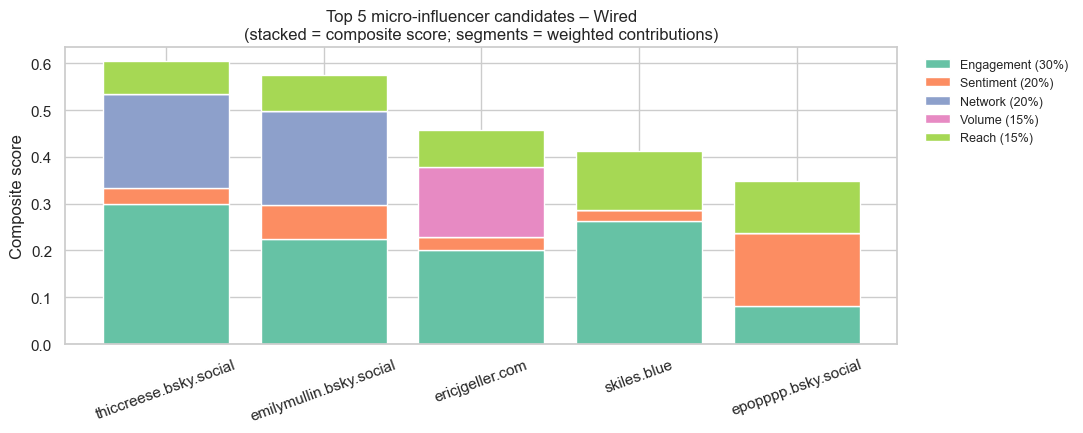

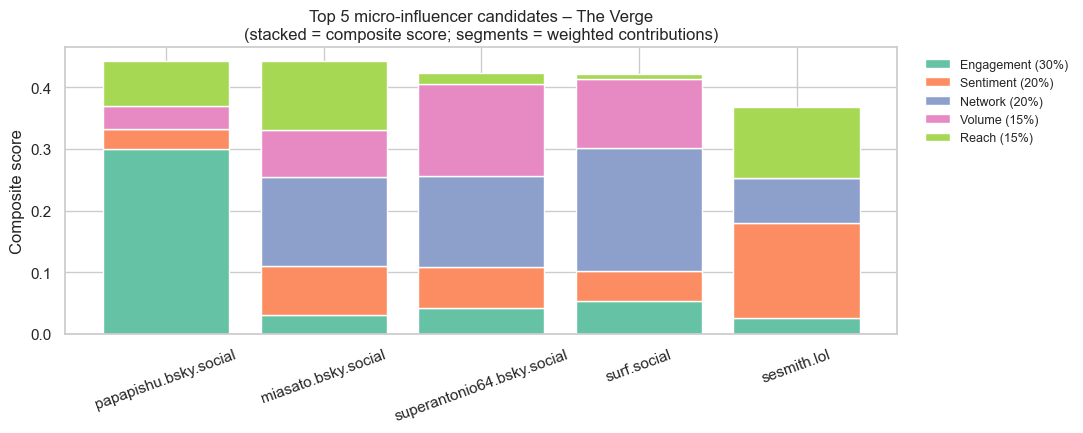

In [17]:
def plot_top_candidates(scored: pd.DataFrame, brand: str, fname: str, top_n: int = 5) -> None:
    if scored.empty:
        print(f"No qualifying candidates for {brand}")
        return
    top = scored.head(top_n).copy()
    components = ["norm_engagement_per_post", "norm_mean_compound",
                  "norm_eigenvector", "norm_posts", "norm_followers_count"]
    component_labels = ["Engagement", "Sentiment", "Network", "Volume", "Reach"]
    weights = list(WEIGHTS.values())

    fig, ax = plt.subplots(figsize=(11, 4.5))
    bottoms = np.zeros(len(top))
    palette = sns.color_palette("Set2", n_colors=len(components))
    for comp, label, w, color in zip(components, component_labels, weights, palette):
        contribution = top[comp].to_numpy() * w
        ax.bar(top["handle"], contribution, bottom=bottoms,
               label=f"{label} ({w:.0%})", color=color)
        bottoms += contribution

    ax.set_title(f"Top {top_n} micro-influencer candidates – {brand}\n"
                 f"(stacked = composite score; segments = weighted contributions)")
    ax.set_ylabel("Composite score")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()

plot_top_candidates(wired_scored, "Wired",     "14_wired_top_candidates.png")
plot_top_candidates(verge_scored, "The Verge", "15_verge_top_candidates.png")

In [18]:
def make_recommendation(scored: pd.DataFrame, brand: str) -> dict:
    if scored.empty:
        return {"brand": brand, "recommendation": None, "reason": "No candidates passed the filter set."}
    top = scored.iloc[0]
    return {
        "brand": brand,
        "recommended_handle":      str(top["handle"]),
        "display_name":            str(top.get("display_name", "")),
        "did":                     str(top["author_did"]),
        "followers_count":         int(top["followers_count"]),
        "follows_count":           int(top["follows_count"]),
        "follower_following_ratio": round(float(top["follower_following_ratio"]), 2),
        "brand_posts":             int(top["posts"]),
        "mean_likes_per_post":     round(float(top["mean_likes"]), 2),
        "mean_reposts_per_post":   round(float(top["mean_reposts"]), 2),
        "engagement_per_post":     round(float(top["engagement_per_post"]), 2),
        "mean_compound_polarity":  round(float(top["mean_compound"]), 3),
        "pct_positive_posts":      round(float(top["pct_positive"]), 1),
        "eigenvector_centrality":  round(float(top["eigenvector"]), 4),
        "composite_score":         round(float(top["composite_score"]), 4),
        "scoring_weights":         WEIGHTS,
    }

recommendations = {
    "wired":      make_recommendation(wired_scored, "Wired"),
    "verge":      make_recommendation(verge_scored, "The Verge"),
    "filter_criteria": {
        "follower_band":            "1,000-100,000 (standard micro band)",
        "min_brand_posts":          2,
        "min_mean_compound":        "> 0 (positive-leaning)",
        "min_engagement_per_post":  2,
        "min_account_age_days":     90,
    },
    "scoring_method_notes": [
        "Each candidate scored on 5 dimensions, each min-max normalised within the surviving candidate pool.",
        "Weights: engagement-per-post 30%, sentiment 20%, network position 20%, posting volume 15%, reach (followers) 15%.",
        "Engagement-per-post defined as (likes + 2*reposts) / posts — reposts weighted double as they signal endorsement-with-amplification.",
        "Eigenvector centrality used over degree centrality because it captures connection to other influential users, not just raw mention count.",
        "Sentiment uses VADER mean compound from Phase 5 — measures sentiment of the user's posts about the brand, not arbitrary topics.",
    ],
}

with open(PROC_DIR / "influencer_recommendations.json", "w") as f:
    json.dump(recommendations, f, indent=2, default=str)

print("\n=== FINAL RECOMMENDATIONS ===\n")
for brand_key in ("wired", "verge"):
    rec = recommendations[brand_key]
    if rec.get("recommended_handle") is None:
        print(f"{rec['brand']}: NO QUALIFYING CANDIDATE — {rec['reason']}\n")
        continue
    print(f"{rec['brand']}:")
    print(f"  Handle             : @{rec['recommended_handle']}")
    print(f"  Display name       : {rec['display_name']}")
    print(f"  Followers          : {rec['followers_count']:,}")
    print(f"  Brand posts        : {rec['brand_posts']}")
    print(f"  Engagement/post    : {rec['engagement_per_post']}")
    print(f"  Mean polarity      : {rec['mean_compound_polarity']:+.3f}  ({rec['pct_positive_posts']}% positive)")
    print(f"  Eigenvector cent.  : {rec['eigenvector_centrality']}")
    print(f"  Composite score    : {rec['composite_score']}\n")

print(f"Saved -> {PROC_DIR / 'influencer_recommendations.json'}")


=== FINAL RECOMMENDATIONS ===

Wired:
  Handle             : @thiccreese.bsky.social
  Display name       : Reece
  Followers          : 18,266
  Brand posts        : 2
  Engagement/post    : 89.0
  Mean polarity      : +0.173  (50.0% positive)
  Eigenvector cent.  : 0.2081
  Composite score    : 0.6049

The Verge:
  Handle             : @papapishu.bsky.social
  Display name       : Chris Person
  Followers          : 30,463
  Brand posts        : 3
  Engagement/post    : 228.33
  Mean polarity      : +0.144  (33.3% positive)
  Eigenvector cent.  : 0.0
  Composite score    : 0.4432

Saved -> /Users/shreyu/VSCODE/junk/UoN-Business-Analytics/Analytics-Specializations-and-Applications/BUSI4370_CW2/data/processed/influencer_recommendations.json
